In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px  # for interactive graphs
import plotly.graph_objects as go

from statsmodels.tsa.seasonal import seasonal_decompose
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style = "whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

In [2]:
tariff_timeline_df = pd.read_csv('tariff_timeline.csv')
stock_market_df = pd.read_csv('stock_market_reaction.csv')
currency_df = pd.read_csv('currency_impact.csv')
sector_df = pd.read_csv('sector_impact.csv')
inflation_df = pd.read_csv('inflation_response.csv')
trade_volume_df = pd.read_csv('trade_volume_annual.csv')
column_metadata_df = pd.read_csv('column_metadata.csv')

In [3]:
tariff_timeline_df.head()

,date,imposing_country,target_country,sector,tariff_rate_pct,prev_rate_pct,type,legal_basis,estimated_trade_value_usd_bn,retaliation,source,notes,tariff_rate_delta,year,quarter,month
0,2018-03-08,USA,ALL,Steel,25.0,0.0,New Tariff,Section 232,29.0,False,Federal Register,Trump signs 25% global steel tariffs under nat...,25.0,2018,2018Q1,2018-03
1,2018-03-08,USA,ALL,Aluminum,10.0,0.0,New Tariff,Section 232,17.0,False,Federal Register,Trump signs 10% global aluminum tariffs under ...,10.0,2018,2018Q1,2018-03
2,2018-06-01,EU27,USA,"Steel, Consumer, Agriculture",25.0,0.0,Retaliation,EU Safeguard Regulation,3.4,True,European Commission,"EU retaliates on Harley-Davidson, bourbon, ste...",25.0,2018,2018Q2,2018-06
3,2018-06-01,CAN,USA,"Steel, Aluminum, Consumer",25.0,0.0,Retaliation,Customs Tariff Act,16.6,True,Canada.ca,Canada dollar-for-dollar retaliation on C$16.6...,25.0,2018,2018Q2,2018-06
4,2018-06-05,MEX,USA,"Steel, Pork, Cheese, Apples",20.0,0.0,Retaliation,Mexican Customs Law,3.0,True,Economy Ministry Mexico,Mexico targets US farm products and steel in t...,20.0,2018,2018Q2,2018-06


In [4]:
stock_market_df.head()

,date,country,index_name,ticker,open,high,low,close,volume,daily_return_pct,weekly_return_pct,ma_20d,ma_50d,volatility_20d,indexed_to_100,tariff_event_nearby
0,2018-01-02,USA,S&P 500 (USA),^GSPC,2683.729980,2695.889893,2682.360107,2695.810059,3397430000,NaN,NaN,NaN,NaN,NaN,100.000000,False
1,2018-01-03,USA,S&P 500 (USA),^GSPC,2697.850098,2714.370117,2697.770020,2713.060059,3544030000,0.639882,NaN,NaN,NaN,NaN,100.639882,False
2,2018-01-04,USA,S&P 500 (USA),^GSPC,2719.310059,2729.290039,2719.070068,2723.989990,3697340000,0.402864,NaN,NaN,NaN,NaN,101.045323,False
3,2018-01-05,USA,S&P 500 (USA),^GSPC,2731.330078,2743.449951,2727.919922,2743.149902,3239280000,0.703377,NaN,NaN,NaN,NaN,101.756053,False
4,2018-01-08,USA,S&P 500 (USA),^GSPC,2742.669922,2748.510010,2737.600098,2747.709961,3246160000,0.166234,NaN,NaN,NaN,NaN,101.925206,False


In [5]:
currency_df.head()

,date,currency,country,rate_vs_usd,pct_change_1d,pct_change_7d,pct_change_30d,rolling_30d_avg,rolling_7d_vol,tariff_event_nearby
0,2018-01-01,CNY,China,6.5057,NaN,NaN,NaN,NaN,NaN,False
1,2018-01-02,CNY,China,6.5058,0.001532,NaN,NaN,NaN,NaN,False
2,2018-01-03,CNY,China,6.4940,-0.181374,NaN,NaN,NaN,NaN,False
3,2018-01-04,CNY,China,6.5031,0.140129,NaN,NaN,NaN,NaN,False
4,2018-01-05,CNY,China,6.4933,-0.150697,NaN,NaN,NaN,NaN,False


In [6]:
sector_df.head()

,date,country,sector,sector_label,ticker,tariff_sensitivity,open,high,low,close,volume,daily_return_pct,weekly_return_pct,indexed_to_100,volatility_10d
0,2018-01-02,USA,Technology,Technology (USA),XLK,High,29.628368,29.872925,29.554541,29.872925,27445600,NaN,NaN,100.000000,NaN
1,2018-01-03,USA,Technology,Technology (USA),XLK,High,29.928296,30.140553,29.895996,30.122095,22663600,0.834101,NaN,100.834101,NaN
2,2018-01-04,USA,Technology,Technology (USA),XLK,High,30.242072,30.352814,30.172857,30.274372,21493200,0.505533,NaN,101.343850,NaN
3,2018-01-05,USA,Technology,Technology (USA),XLK,High,30.431263,30.620450,30.371278,30.592766,19356000,1.051694,NaN,102.409677,NaN
4,2018-01-08,USA,Technology,Technology (USA),XLK,High,30.578911,30.763484,30.560457,30.708115,13467800,0.377046,NaN,102.795809,NaN


In [7]:
inflation_df.head()

,date,country,metric,category,series_label,fred_series,value,mom_change_pct,yoy_change_pct,era,post_tariff_era
0,2015-01-01,USA,CPI,All Items,USA_CPI_All,CPIAUCSL,234.747,NaN,NaN,Pre-Trade War,False
1,2015-02-01,USA,CPI,All Items,USA_CPI_All,CPIAUCSL,235.342,0.253464,NaN,Pre-Trade War,False
2,2015-03-01,USA,CPI,All Items,USA_CPI_All,CPIAUCSL,235.976,0.269395,NaN,Pre-Trade War,False
3,2015-04-01,USA,CPI,All Items,USA_CPI_All,CPIAUCSL,236.222,0.104248,NaN,Pre-Trade War,False
4,2015-05-01,USA,CPI,All Items,USA_CPI_All,CPIAUCSL,237.001,0.329775,NaN,Pre-Trade War,False


In [8]:
trade_volume_df.head()

,year,country_code,country,type,indicator,indicator_name,value,yoy_change_pct,period
0,2015,US,USA,Trade,NE.EXP.GNFS.CD,Exports of goods & services (USD),2.270622e+12,NaN,Pre-Trade War
1,2016,US,USA,Trade,NE.EXP.GNFS.CD,Exports of goods & services (USD),2.235558e+12,-1.544246,Pre-Trade War
2,2017,US,USA,Trade,NE.EXP.GNFS.CD,Exports of goods & services (USD),2.388260e+12,6.830599,Pre-Trade War
3,2018,US,USA,Trade,NE.EXP.GNFS.CD,Exports of goods & services (USD),2.538089e+12,6.273563,Trade War 1.0
4,2019,US,USA,Trade,NE.EXP.GNFS.CD,Exports of goods & services (USD),2.539391e+12,0.051298,Trade War 1.0


In [10]:
column_metadata_df

,file,column,dtype,description
0,tariff_timeline.csv,date,date,Date of tariff announcement or implementation ...
1,tariff_timeline.csv,imposing_country,string,ISO code of the country imposing the tariff (U...
2,tariff_timeline.csv,target_country,string,ISO code of the country or region receiving th...
3,tariff_timeline.csv,sector,string,"Economic sector targeted (All Goods, Steel, EV..."
4,tariff_timeline.csv,tariff_rate_pct,float,New tariff rate as a percentage of import value
...,...,...,...,...
57,trade_volume_annual.csv,indicator_name,string,Human-readable indicator description
58,trade_volume_annual.csv,type,string,Indicator category: Trade / GDP / Inflation / ...
59,trade_volume_annual.csv,value,float,Numeric value of the indicator for that countr...
60,trade_volume_annual.csv,yoy_change_pct,float,Year-over-year percentage change in the indica...


## Data Preprocessing

In [20]:
dfs_list = {
    "tariff_timeline": tariff_timeline_df,
    "stock_market_reaction": stock_market_df,
    "currency_impact": currency_df,
    "sector_impact": sector_df,
    "inflation_response": inflation_df,
    "trade_volume_annual": trade_volume_df
}

In [21]:
preprocessing_summary = []

In [22]:
for name, df in dfs_list.items():

    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])

    info = {
        "name" : name,
        "rows": len(df),
        "cols" : len(df.columns),
        "missing_values": df.isnull().sum().sum(),
        "date_min": df["date"].min() if "date" in df.columns else "N/A",
        "date_max" : df["date"].max() if "date" in df.columns else "N/A",
    }
    preprocessing_summary.append(info)
    

In [23]:
summary_df = pd.DataFrame(preprocessing_summary)

In [24]:
summary_df

,name,rows,cols,missing_values,date_min,date_max
0,tariff_timeline,45,16,6,2018-03-08 00:00:00,2026-04-13 00:00:00
1,stock_market_reaction,34508,16,1598,2018-01-01 00:00:00,2026-04-30 00:00:00
2,currency_impact,32533,10,1095,2018-01-01 00:00:00,2026-05-01 00:00:00
3,sector_impact,33488,15,256,2018-01-02 00:00:00,2026-04-30 00:00:00
4,inflation_response,1884,11,182,2015-01-01 00:00:00,2026-04-01 00:00:00
5,trade_volume_annual,1515,9,150,N/A,N/A


In [25]:
sector_df.isnull().sum()

date                    0
country                 0
sector                  0
sector_label            0
ticker                  0
tariff_sensitivity      0
open                    0
high                    0
low                     0
close                   0
volume                  0
daily_return_pct       16
weekly_return_pct      80
indexed_to_100          0
volatility_10d        160
dtype: int64

## EDA

#### Univariate Analysis on Data Frames

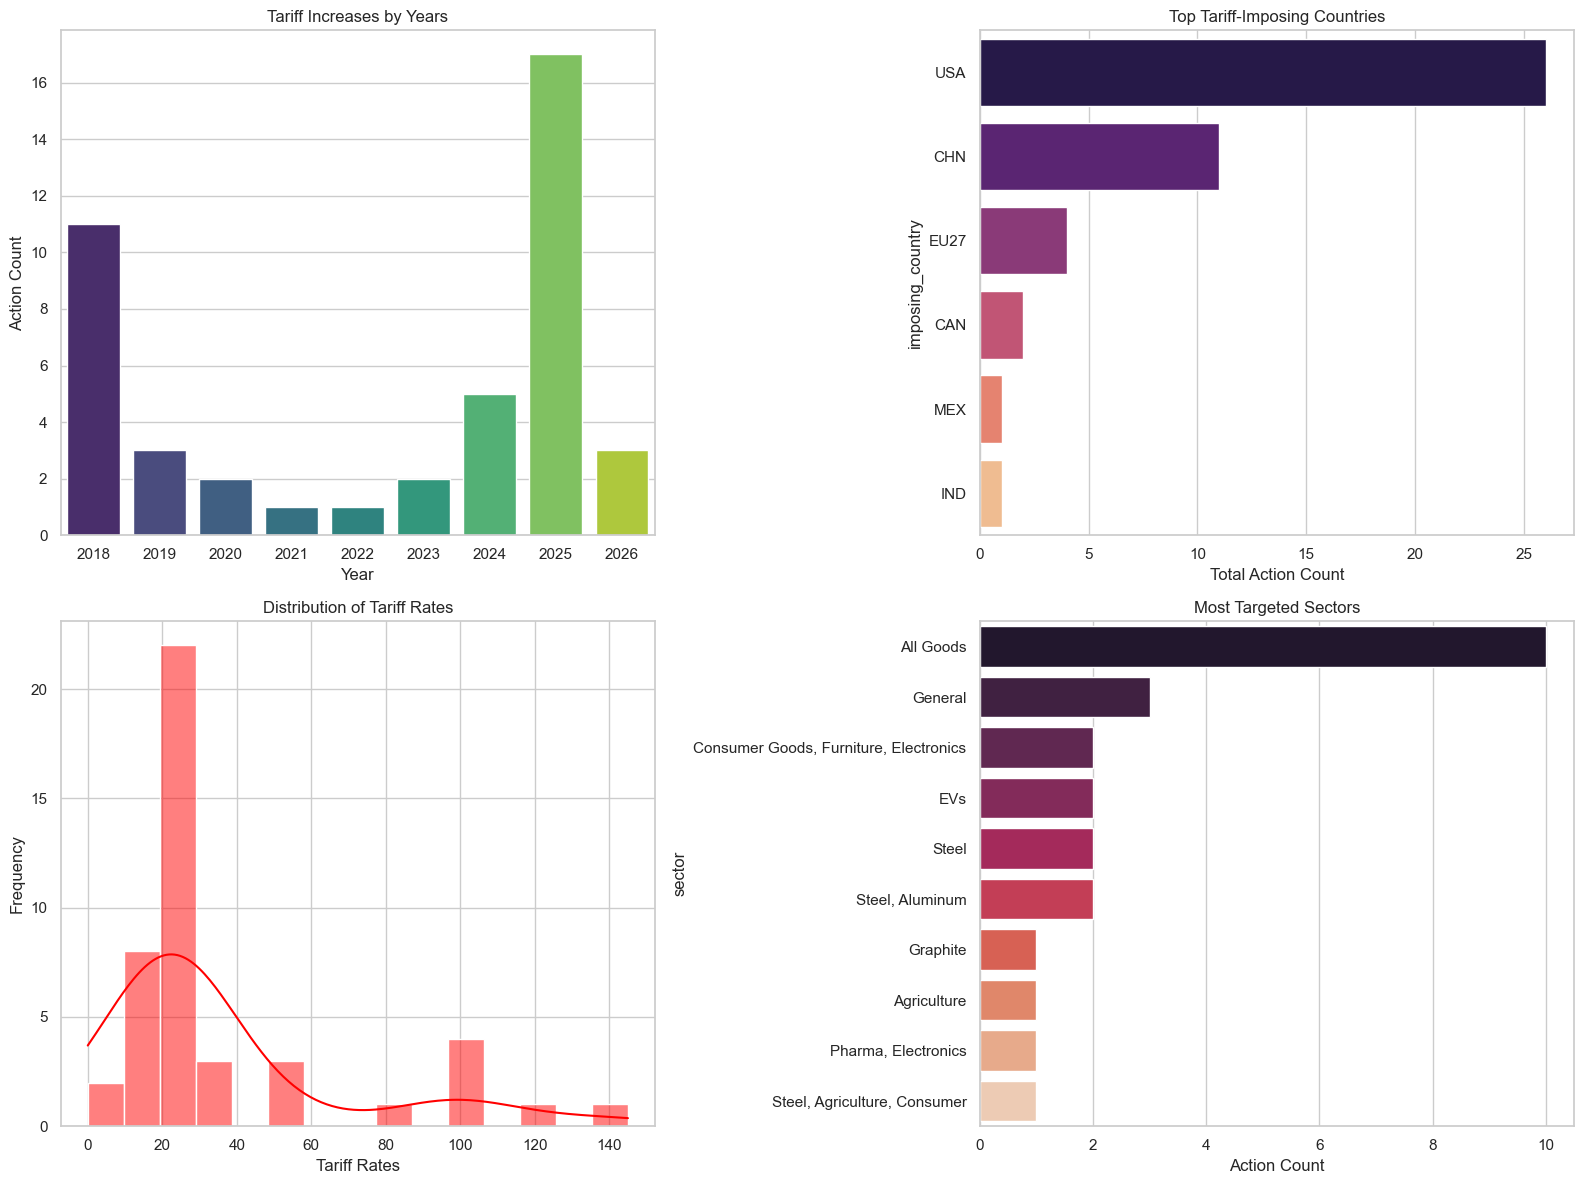

In [40]:
fig, axes = plt.subplots(2,2, figsize = (16,12))

sns.countplot(data = tariff_timeline_df, x = "year", palette = "viridis", ax = axes[0,0])
axes[0,0].set_title("Tariff Increases by Years")
axes[0,0].set_ylabel("Action Count")
axes[0,0].set_xlabel("Year")

country_counts = tariff_timeline_df["imposing_country"].value_counts()
sns.barplot(x = country_counts.values, y = country_counts.index, palette = "magma", ax = axes[0,1])
axes[0,1].set_title("Top Tariff-Imposing Countries")
axes[0,1].set_xlabel("Total Action Count")

sns.histplot(tariff_timeline_df["tariff_rate_pct"], bins = 15, kde = True, color = "red", ax = axes[1,0])
axes[1,0].set_title("Distribution of Tariff Rates")
axes[1,0].set_xlabel("Tariff Rates")
axes[1,0].set_ylabel("Frequency")

sector_counts = tariff_timeline_df["sector"].value_counts().head(10)
sns.barplot(x = sector_counts.values, y = sector_counts.index, palette = "rocket", ax = axes[1,1])
axes[1,1].set_title("Most Targeted Sectors")
axes[1,1].set_xlabel("Action Count")

plt.tight_layout()
plt.show()

In [29]:
# finding the most popular index in ticker column
stock_market_df["ticker"].value_counts()

ticker
^FCHI        2131
^GDAXI       2113
^AXJO        2106
^FTSE        2103
^MXX         2093
^IXIC        2093
^GSPC        2093
^DJI         2093
VNM          2093
^GSPTSE      2091
^BVSP        2068
^BSESN       2048
^HSI         2047
^KS11        2042
^N225        2031
000001.SS    2017
000300.SS    1246
Name: count, dtype: int64

In [30]:
# filtering the most popular index by ticker column
market_index = stock_market_df[stock_market_df["ticker"] == "^GSPC"]

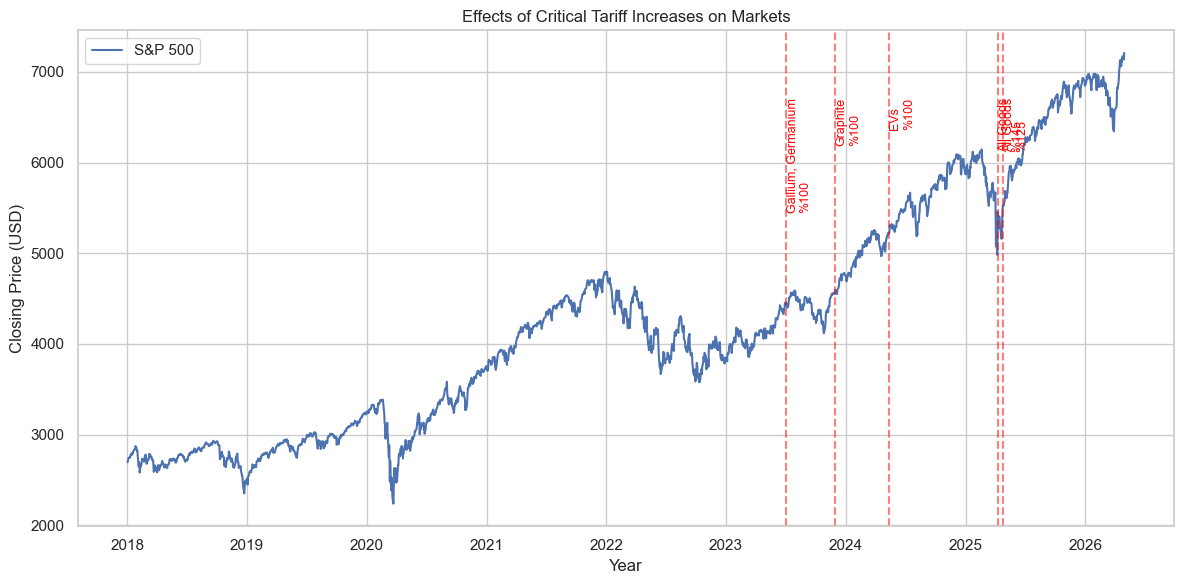

In [33]:
plt.plot(market_index["date"], market_index["close"], label = "S&P 500", linewidth =1.5)

significant_tarifs = tariff_timeline_df.nlargest(5, "tariff_rate_pct") # top 5 most significant tariff increases.

for i, row in significant_tarifs.iterrows():
    plt.axvline(x = row["date"], color = "red", linestyle = "--", alpha = 0.5)
    plt.text(row["date"], plt.ylim()[1]*0.9, f"{row["sector"]}\n%{int(row["tariff_rate_pct"])}",
            rotation = 90, color = "red", fontsize = 9, verticalalignment = "top")

plt.title("Effects of Critical Tariff Increases on Markets")
plt.xlabel("Year")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()